In [349]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.total_variation import total_variation
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA
from sklearn.manifold import MDS

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd
from collections import Counter

from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import community as community_louvain
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

from itertools import chain

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


# load distribution

In [351]:
style_file = "utils.style"
plt.style.use(style_file)

distances = {
    "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

In [355]:

embd_smart_orange = np.load(os.path.join(root_path, "embd_n_mask", "embd_before_procrustes", "embd_smart_orange.npy"))
embd_tasic_orange = np.load(os.path.join(root_path,  "embd_n_mask", "embd_before_procrustes","embd_tasic_orange.npy"))
embd_10x_orange = np.load(os.path.join(root_path,  "embd_n_mask", "embd_before_procrustes","embd_10x_orange_20k.npy"))

In [356]:
root_path = get_path("data")
dist_tasic_orange = load_dict(os.path.join(root_path, "77test_dist", "dist_tasic_orange.pkl"))
dist_yao_orange = load_dict(os.path.join(root_path,"77test_dist", "dist_smart_orange.pkl"))
dist_10x_orange = load_dict(os.path.join(root_path,"77test_dist", "dist_10x_orange.pkl"))


In [359]:
def reshape_dist(dist, num = None):
    #num: number of loops per condition
    full_dist = list(dist.keys())[1:]
    size = len(dist[list(dist.keys())[0]])
    result = np.zeros((1,size))
    ticks = []
    # shorten_dist = ['euclidean',
    #     'diffusion_k_15_t_8',
    #     'diffusion_k_100_t_8',
    #     'diffusion_k_15_t_64',
    #     'diffusion_k_100_t_64',
    #     'eff_res_k_15',
    #     'eff_res_k_100']
    shorten_dist = ['euc',
        'diff_15_8',
        'diff_100_8',
        'diff_15_64',
        'diff_100_64',
        'eff_15',
        'eff_100']
    for shorten, condition in zip(shorten_dist, full_dist):
        if num is not None:
            result = np.vstack((result, np.array(dist[condition][:int(num)])))
            ticks.extend([f"{shorten}"+f"_{i}"for i in range(num)])
        else:
            result = np.vstack((result, np.array(dist[condition])))
            ticks.extend([f"{shorten}"+f"_{i}"for i in range(7)])
    return ticks, result[1:,:]

In [360]:
ticks, reshape_tasic_orange = reshape_dist(dist_tasic_orange,7)
_, reshape_yao_orange = reshape_dist(dist_yao_orange,7)
_, reshape_10x_orange = reshape_dist(dist_10x_orange,7)

In [361]:
def complete_linkage(mat, threshold = 0.4):
    link = linkage(squareform(mat), method='complete')
    clusters = fcluster(link, t=threshold, criterion='distance')
    
    row_dendr = dendrogram(link)
    # print(pd.DataFrame(link, 
    #          columns=['row label 1', 'row label 2', 'distance', 'no. of items in clust.'],
    #          index=['cluster %d' %(i+1) for i in range(link.shape[0])]))
    
    list_of_communities = [[] for _ in range(max(clusters))]
    for i, cluster in enumerate(clusters):
        list_of_communities[cluster-1].append(i)
    
    return clusters, list_of_communities

In [363]:
def total_variation_matrix(reshaped_array1, reshaped_array2):
    size = reshaped_array1.shape[0]
    result = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            result[i][j] = total_variation(reshaped_array1[i,:], reshaped_array2[j,:])
    return result

In [365]:
def fig_pigeonhole_loops(list_of_communities, matrix, ticks, title, threshold = None, ungroups = 1, saveas = None):
    size = len(list_of_communities)
    
    fig, ax = plt.subplots(size, 2, figsize=(4, size))
    ax[0][0].set_title("                                    loops in groups", fontsize=7)
    for i in range(size):
        loops_idx = list_of_communities[i]
        size_loops = len(loops_idx)
        submatrix = matrix[np.ix_(loops_idx, loops_idx)]
        values, base = np.histogram(submatrix.flatten(), bins=100)
        cumulative = np.cumsum(values)
        fig.suptitle(title)
        
        ax[i, 0].plot(base[:-1], cumulative/cumulative[-1], c='blue')
        ax[i, 0].set_xlim([0, 1])
        ax[i, 0].set_xlabel("Total variation")
        # ax[i, 0].set_ylabel("% of pairs of conditions")
        if threshold is not None:
            ax[i, 0].axvline(threshold[i], c="red")
            submatrix = np.where(submatrix > threshold[i], threshold[i], submatrix)
    
        ax1 = ax[i,1].imshow(submatrix, cmap='grey')
        
        ytick = [f"{a}_{np.array(ticks)[a]}"for a in loops_idx]
        ax[i,1].set_yticks(range(size_loops), ytick, size='small') #np.array(ticks)[loops_idx]
        ax[i,1].set_xticks(range(size_loops), loops_idx, size='small', rotation=90, ha='right')# np.array(ticks)[loops_idx]
        # ax[i,1].set_ylabel(title.split('*')[0])
        # ax[i,1].set_xlabel(title.split('*')[-1])
        waht = fig.colorbar(ax1, ax=ax[i, 1])
    if ungroups == 1:
        ax[size-1][0].set_title("                                    ungroupable loops", fontsize=7)
    plt.show()
    if saveas is not None:
        fig.savefig(os.path.join(get_path("figures"), saveas), dpi=300)
    

In [389]:
def pic_pigeonhole_loops(partition, ticks, dataset, embd_n_mask, xlim = None, ylim = None, saveas = None):
    if type(embd_n_mask) is tuple:
        embd_n_mask = embd_n_mask[0][embd_n_mask[1]]
    rows = len(set(partition.values()))
    columns = np.max([list(partition.values()).count(value) for value in range(rows)])
    
    width_ratios = [0.75] + [1] * (columns-1)
    fig, ax = plt.subplots(rows, columns, figsize=(columns*1, rows*1), constrained_layout=True) #, width_ratios=width_ratios
    
    distances = {
        "euclidean": [{}],
            "diffusion": [
            {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
        ],
        "eff_res": [
            {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
            {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        ],
    }
    root_path = get_path("data")
    all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

    # n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
    # n_cols = 8
    # mid_col = np.floor(n_cols/2)
    plot_loops = True
    colors = ['#d714fb', '#006100', '#5d0014', '#75ff3d', '#ffcef3', '#656979', '#db0c59']
    idx = 0
    pos_list = [0]*rows
    for distance in distances.keys():
        for full_dist in all_res[distance]:
            res = all_res[distance][full_dist]
            life_times_loops = get_life_times(res, dim=1)
            loop_idx_sorted = np.argsort(life_times_loops)[::-1][:7]
            for n in range(7):
                row = partition[idx]
                cax = ax[row][pos_list[row]]
                cax.set_title(idx, fontsize=7)
                if ylim is not None:
                    cax.set_ylim(*ylim)
                if xlim is not None:
                    cax.set_xlim(*xlim)
                plot_scatter(cax, embd_n_mask, y="k", s=1, alpha=1, scalebar=False)
                plot_edges_on_scatter(ax=cax,
                                 edge_idx=res["cycles"][1][loop_idx_sorted[n]],
                                 x=embd_n_mask,
                                 color=colors[n],
                                 linewidth=1)
            #we assume there's loop everywhere..........a
                pos_list[row]+=1
                idx+=1
    for axx in ax.flat:
        axx.axis('off')
    fig.suptitle(dataset, fontsize = 16)       
    plt.show()
    if saveas is not None:
        fig.savefig(os.path.join(get_path("figures"), saveas), dpi=300)

In [367]:
def turn_to_partition(list_of_communities_corrected):
    manual_partition = {num: idx for idx, sublist in enumerate(list_of_communities_corrected) for num in sublist}
    manual_partition = dict(sorted(manual_partition.items()))
    return manual_partition

# 10x orange * 10x orange

In [ ]:
mat = total_variation_matrix(reshape_10x_orange, reshape_10x_orange)
clusters, list_of_communities = complete_linkage(mat, threshold =0.7)
partition = turn_to_partition(list_of_communities)

In [ ]:
for i in list_of_communities:
    print(i)

In [ ]:
fig_pigeonhole_loops(list_of_communities, mat, ticks, title = "10x_orange", threshold = None, ungroups = None, saveas = None)

In [ ]:
pic_pigeonhole_loops(partition, ticks, "yao_10x_male_orange_sample", embd_orange_10x, xlim = None, ylim = (30, 90), saveas = "pic_10x_orange.png") 

# tri orange

In [368]:
mat_tasic = total_variation_matrix(reshape_tasic_orange, reshape_tasic_orange)
mat_yao = total_variation_matrix(reshape_yao_orange, reshape_yao_orange)
mat_10x = total_variation_matrix(reshape_10x_orange, reshape_10x_orange)
mat_t_y = total_variation_matrix(reshape_tasic_orange, reshape_yao_orange)
mat_t_10 = total_variation_matrix(reshape_tasic_orange, reshape_10x_orange)
mat_y_10 = total_variation_matrix(reshape_yao_orange, reshape_10x_orange)

In [369]:
def complete_linkage_tri(threshold = 0.8):
    size = mat_tasic.shape[0]
    
    np.random.seed(0)
    zeros = np.zeros(mat_y_10.shape)
    tri_mat_raw = np.block([[mat_tasic, mat_t_y, mat_t_10],[zeros,mat_yao,mat_y_10],[zeros,zeros,mat_10x]])
    upper_tri = np.triu(tri_mat_raw)
    tri_mat = upper_tri + upper_tri.T
    np.fill_diagonal(tri_mat, 0)
    
    link = linkage(squareform(tri_mat), method='complete')
    clusters = fcluster(link, t=threshold, criterion='distance')
    
    row_dendr = dendrogram(link)
    
    list_of_communities = [[] for _ in range(max(clusters))]
    for i, cluster in enumerate(clusters):
        list_of_communities[cluster-1].append(i)    
        
    trim_list_of_communities = []
    waste = []
    for lst in list_of_communities:
        if any(x <49 for x in lst) and any(49 <= x and x  < 2*49 for x in lst) and any(x >= 2*49 for x in lst):
            trim_list_of_communities.append(lst)
        else:
            waste.append(lst)
    trim_list_of_communities.append(waste)
    
    partition = {}
    part_trim_list_of_communities = trim_list_of_communities[:-1] + trim_list_of_communities[-1]
    for index, lst in enumerate(part_trim_list_of_communities):
        if isinstance(lst, list):
            for number in lst:
                partition[number] = index  
        else:
            partition[lst] = index
    
    return partition, trim_list_of_communities

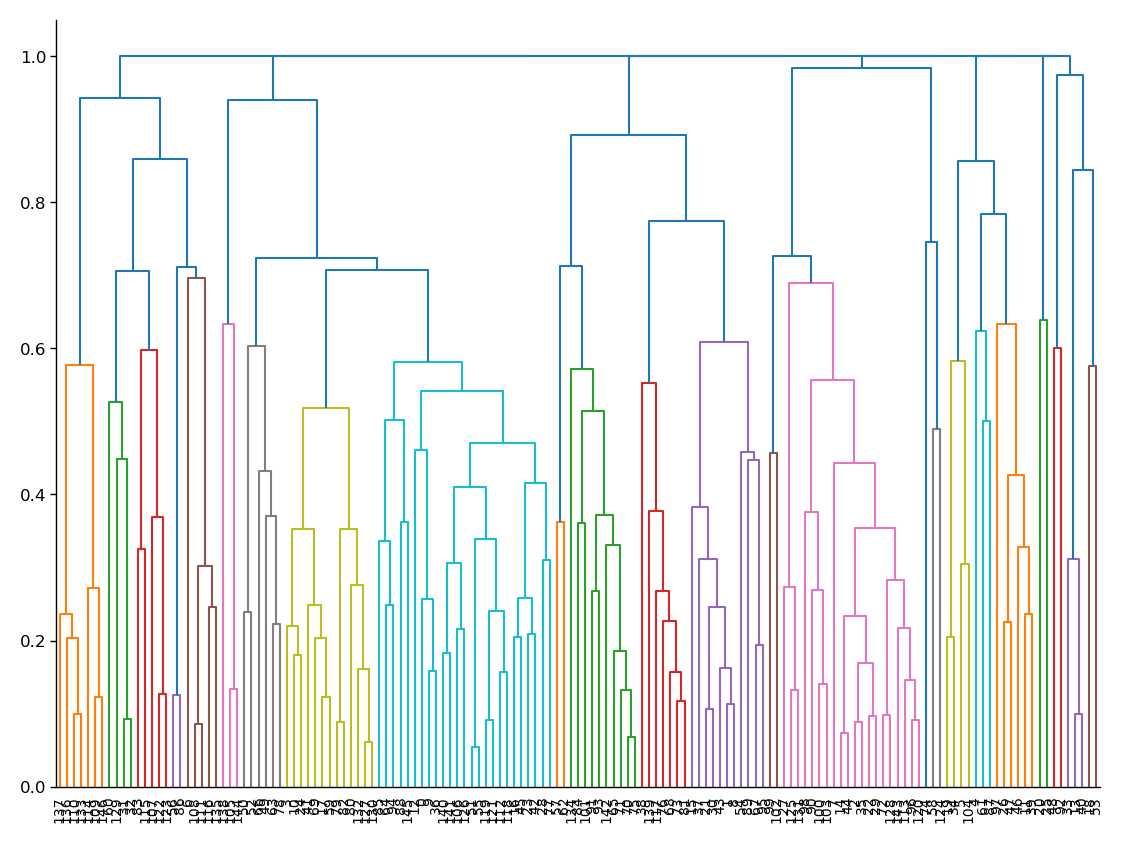

In [370]:
partition, trim_list_of_communities = complete_linkage_tri(threshold = 0.7)

In [371]:
def tune_tri_threshold(lower_b = 0.5, higher_b = 1.0):
    ts = np.arange(lower_b, higher_b, 0.01)
    ave_tv = np.zeros((ts.shape))
    n_tv = np.zeros((ts.shape))
    size = 49
    
    zeros = np.zeros(mat_y_10.shape)
    tri_mat_raw = np.block([[mat_tasic, mat_t_y, mat_t_10],[zeros,mat_yao,mat_y_10],[zeros,zeros,mat_10x]])
    upper_tri = np.triu(tri_mat_raw)
    tri_mat = upper_tri + upper_tri.T
    np.fill_diagonal(tri_mat, 0)
    
    for i, t in enumerate(ts):
        partition, trim_list_of_communities = complete_linkage_tri(threshold = t)
        # print(len(trim_list_of_communities))
        tvs = []
        for l in trim_list_of_communities[:-1]:
            l_tasic = [a for a in l if a <size]
            l_yao = [b for b in l if b >=size and b < 2*size]
            l_10x = [c for c in l if c >2*size]
            # print(i)
            # print([tri_mat[a,b], tri_mat[b,c], tri_mat[a,c]] for a in l_tasic for b in l_yao for c in l_10x)
            tvs = tvs + [np.mean([tri_mat[a,b], tri_mat[b,c], tri_mat[a,c]]) for a in l_tasic for b in l_yao for c in l_10x]
        ave_tv[i] = np.mean(np.array(tvs))
        n_tv[i] = len(tvs)
    return tri_mat, ave_tv, n_tv

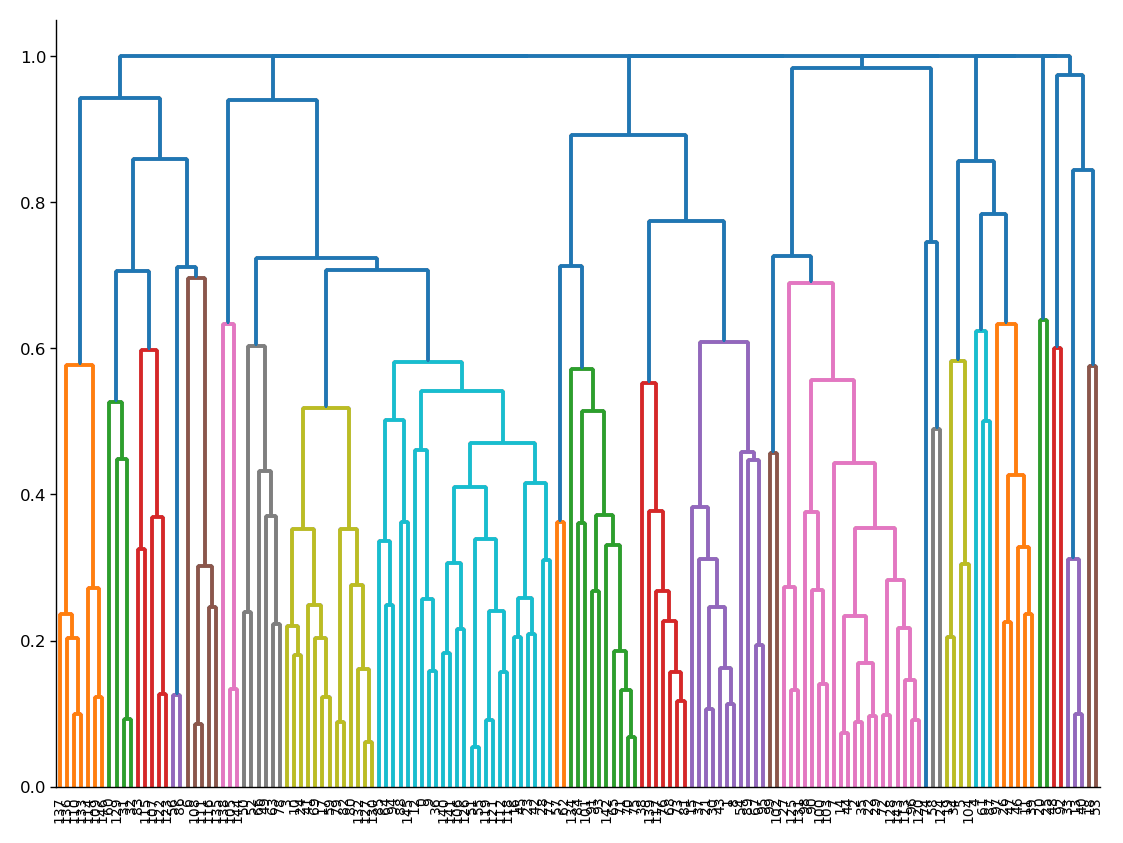

In [ ]:
tri_mat, ave_tv, n_tv =tune_tri_threshold()

In [ ]:
plt.plot(np.arange(0, len(ave_tv), 1), ave_tv)

In [372]:
def fig_tri_pigeonhole_loops(trim_list_of_communities, ticks, title, threshold = None, saveas = None):
    size = len(trim_list_of_communities)
    fig_list_of_communities = trim_list_of_communities.copy()
    # print(len(fig_list_of_communities[-1] ))
    fig_list_of_communities[-1] =  sorted(sum(fig_list_of_communities[-1], []))
    
    fig, ax = plt.subplots(size, 4, figsize=(8, size),  constrained_layout=True)
    ax[0][0].set_title("                                    loops in groups", fontsize=7)
    for i in range(size):
        loops_idx_tasic = [a for a in fig_list_of_communities[i] if a <49]
        loops_idx_yao =  [a-49 for a in fig_list_of_communities[i] if a >= 49 and a < 98]
        loops_idx_10x =  [a-98 for a in fig_list_of_communities[i] if a >= 98]
        
        sub_t_y = mat_t_y[np.ix_(loops_idx_tasic, loops_idx_yao)]
        sub_t_10 = mat_t_10[np.ix_(loops_idx_tasic, loops_idx_10x)]
        sub_y_10 = mat_y_10[np.ix_(loops_idx_yao, loops_idx_10x)]
        
        values, base = np.histogram(np.concatenate((sub_t_y.flatten(),sub_t_10.flatten(),sub_y_10.flatten())), bins=100) #???
        cumulative = np.cumsum(values)
        fig.suptitle(title)
        v_min = np.min(base)
        v_max = np.max(base)
        
        ax[i, 0].plot(base[:-1], cumulative/cumulative[-1], c='blue')
        ax[i, 0].set_xlim([0, 1])
        ax[i, 0].set_xlabel("Total variation")
        # ax[i, 0].set_ylabel("% of pairs of conditions")
        if threshold is not None:
            ax[i, 0].axvline(threshold[i], c="red")
            submatrix = np.where(submatrix > threshold[i], threshold[i], submatrix)
    
        # ax1 = ax[i,1].imshow(submatrix, cmap='grey')
        ax1 = ax[i,1].imshow(sub_t_y, cmap='grey', vmin = v_min, vmax = v_max)
        ytick1 = [f"{a}_{np.array(ticks)[a]}"for a in loops_idx_tasic]
        ax[i,1].set_yticks(range(len(loops_idx_tasic)), ytick1, size='small') #np.array(ticks)[loops_idx]
        ax[i,1].set_xticks(range(len(loops_idx_yao)), [a+49 for a in loops_idx_yao], size='small', rotation=90, ha='right')# np.array(ticks)[loops_idx]
        ax[i,1].set_ylabel("tasic")
        ax[i,1].set_xlabel("smart")
        
        ax2 = ax[i,2].imshow(sub_t_10, cmap='grey', vmin = v_min, vmax = v_max)
        ax[i,2].set_yticks(range(len(loops_idx_tasic)), ytick1, size='small') #np.array(ticks)[loops_idx]
        ax[i,2].set_xticks(range(len(loops_idx_10x)), [a+98 for a in loops_idx_10x], size='small', rotation=90, ha='right')# np.array(ticks)[loops_idx]
        ax[i,2].set_ylabel("tasic")
        ax[i,2].set_xlabel("10x")
        
        ax3 = ax[i,3].imshow(sub_y_10, cmap='grey', vmin = v_min, vmax = v_max)
        ytick2 = [f"{a+49}_{np.array(ticks)[a]}"for a in loops_idx_yao]
        ax[i,3].set_yticks(range(len(loops_idx_yao)), ytick2, size='small') #np.array(ticks)[loops_idx]
        ax[i,3].set_xticks(range(len(loops_idx_10x)), [a+98 for a in loops_idx_10x], size='small', rotation=90, ha='right')# np.array(ticks)[loops_idx]
        ax[i,3].set_ylabel("yao")
        ax[i,3].set_xlabel("10x")
        
        
        waht1 = fig.colorbar(ax1, ax=ax[i, 1])
        waht2 = fig.colorbar(ax2, ax=ax[i, 2])
        waht3 = fig.colorbar(ax3, ax=ax[i, 3])
    ax[size-1][0].set_title("                                    ungroupable loops", fontsize=7)
    plt.show()
    if saveas is not None:
        fig.savefig(os.path.join(get_path("figures"), saveas), dpi=300)

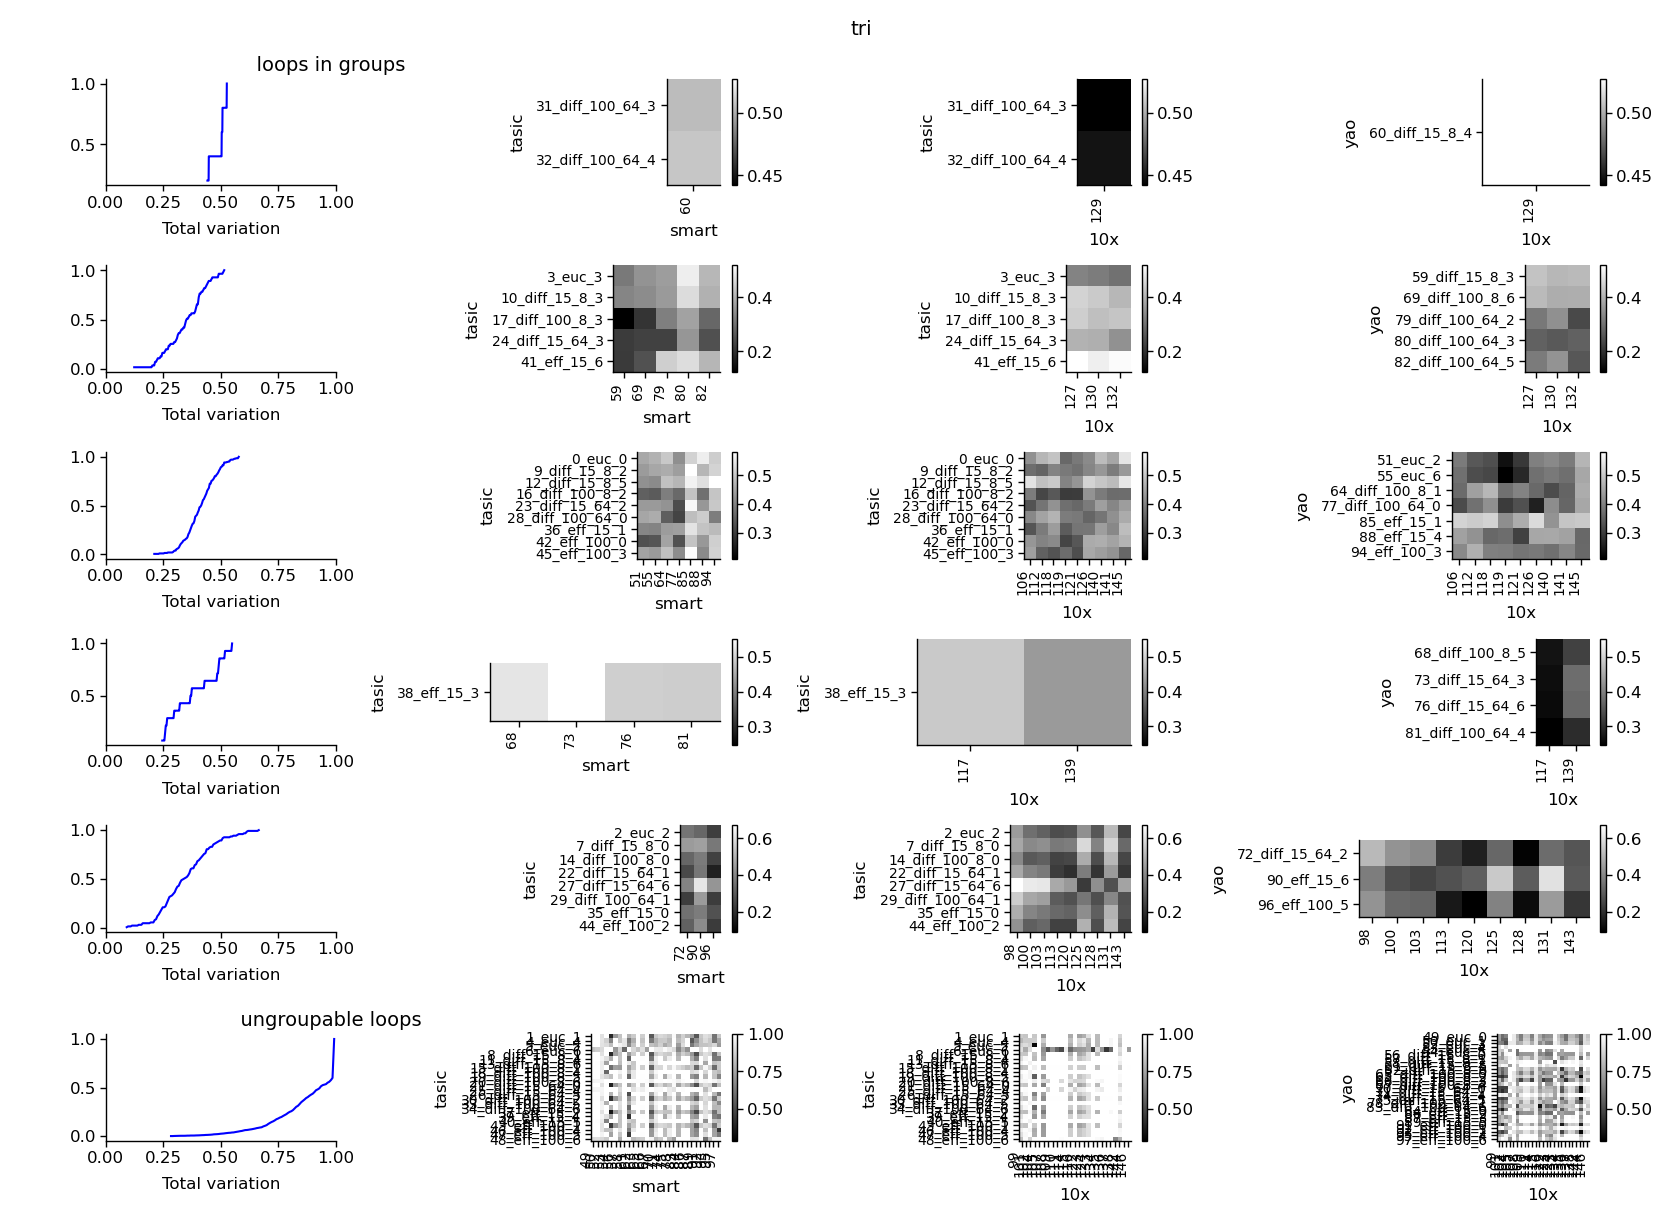

In [ ]:
fig_tri_pigeonhole_loops(trim_list_of_communities, ticks, "tri", threshold = None) #, saveas = "fig_tri_orange.png"

Done with tasic_orange None euclidean n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None euclidean n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_8_kernel_

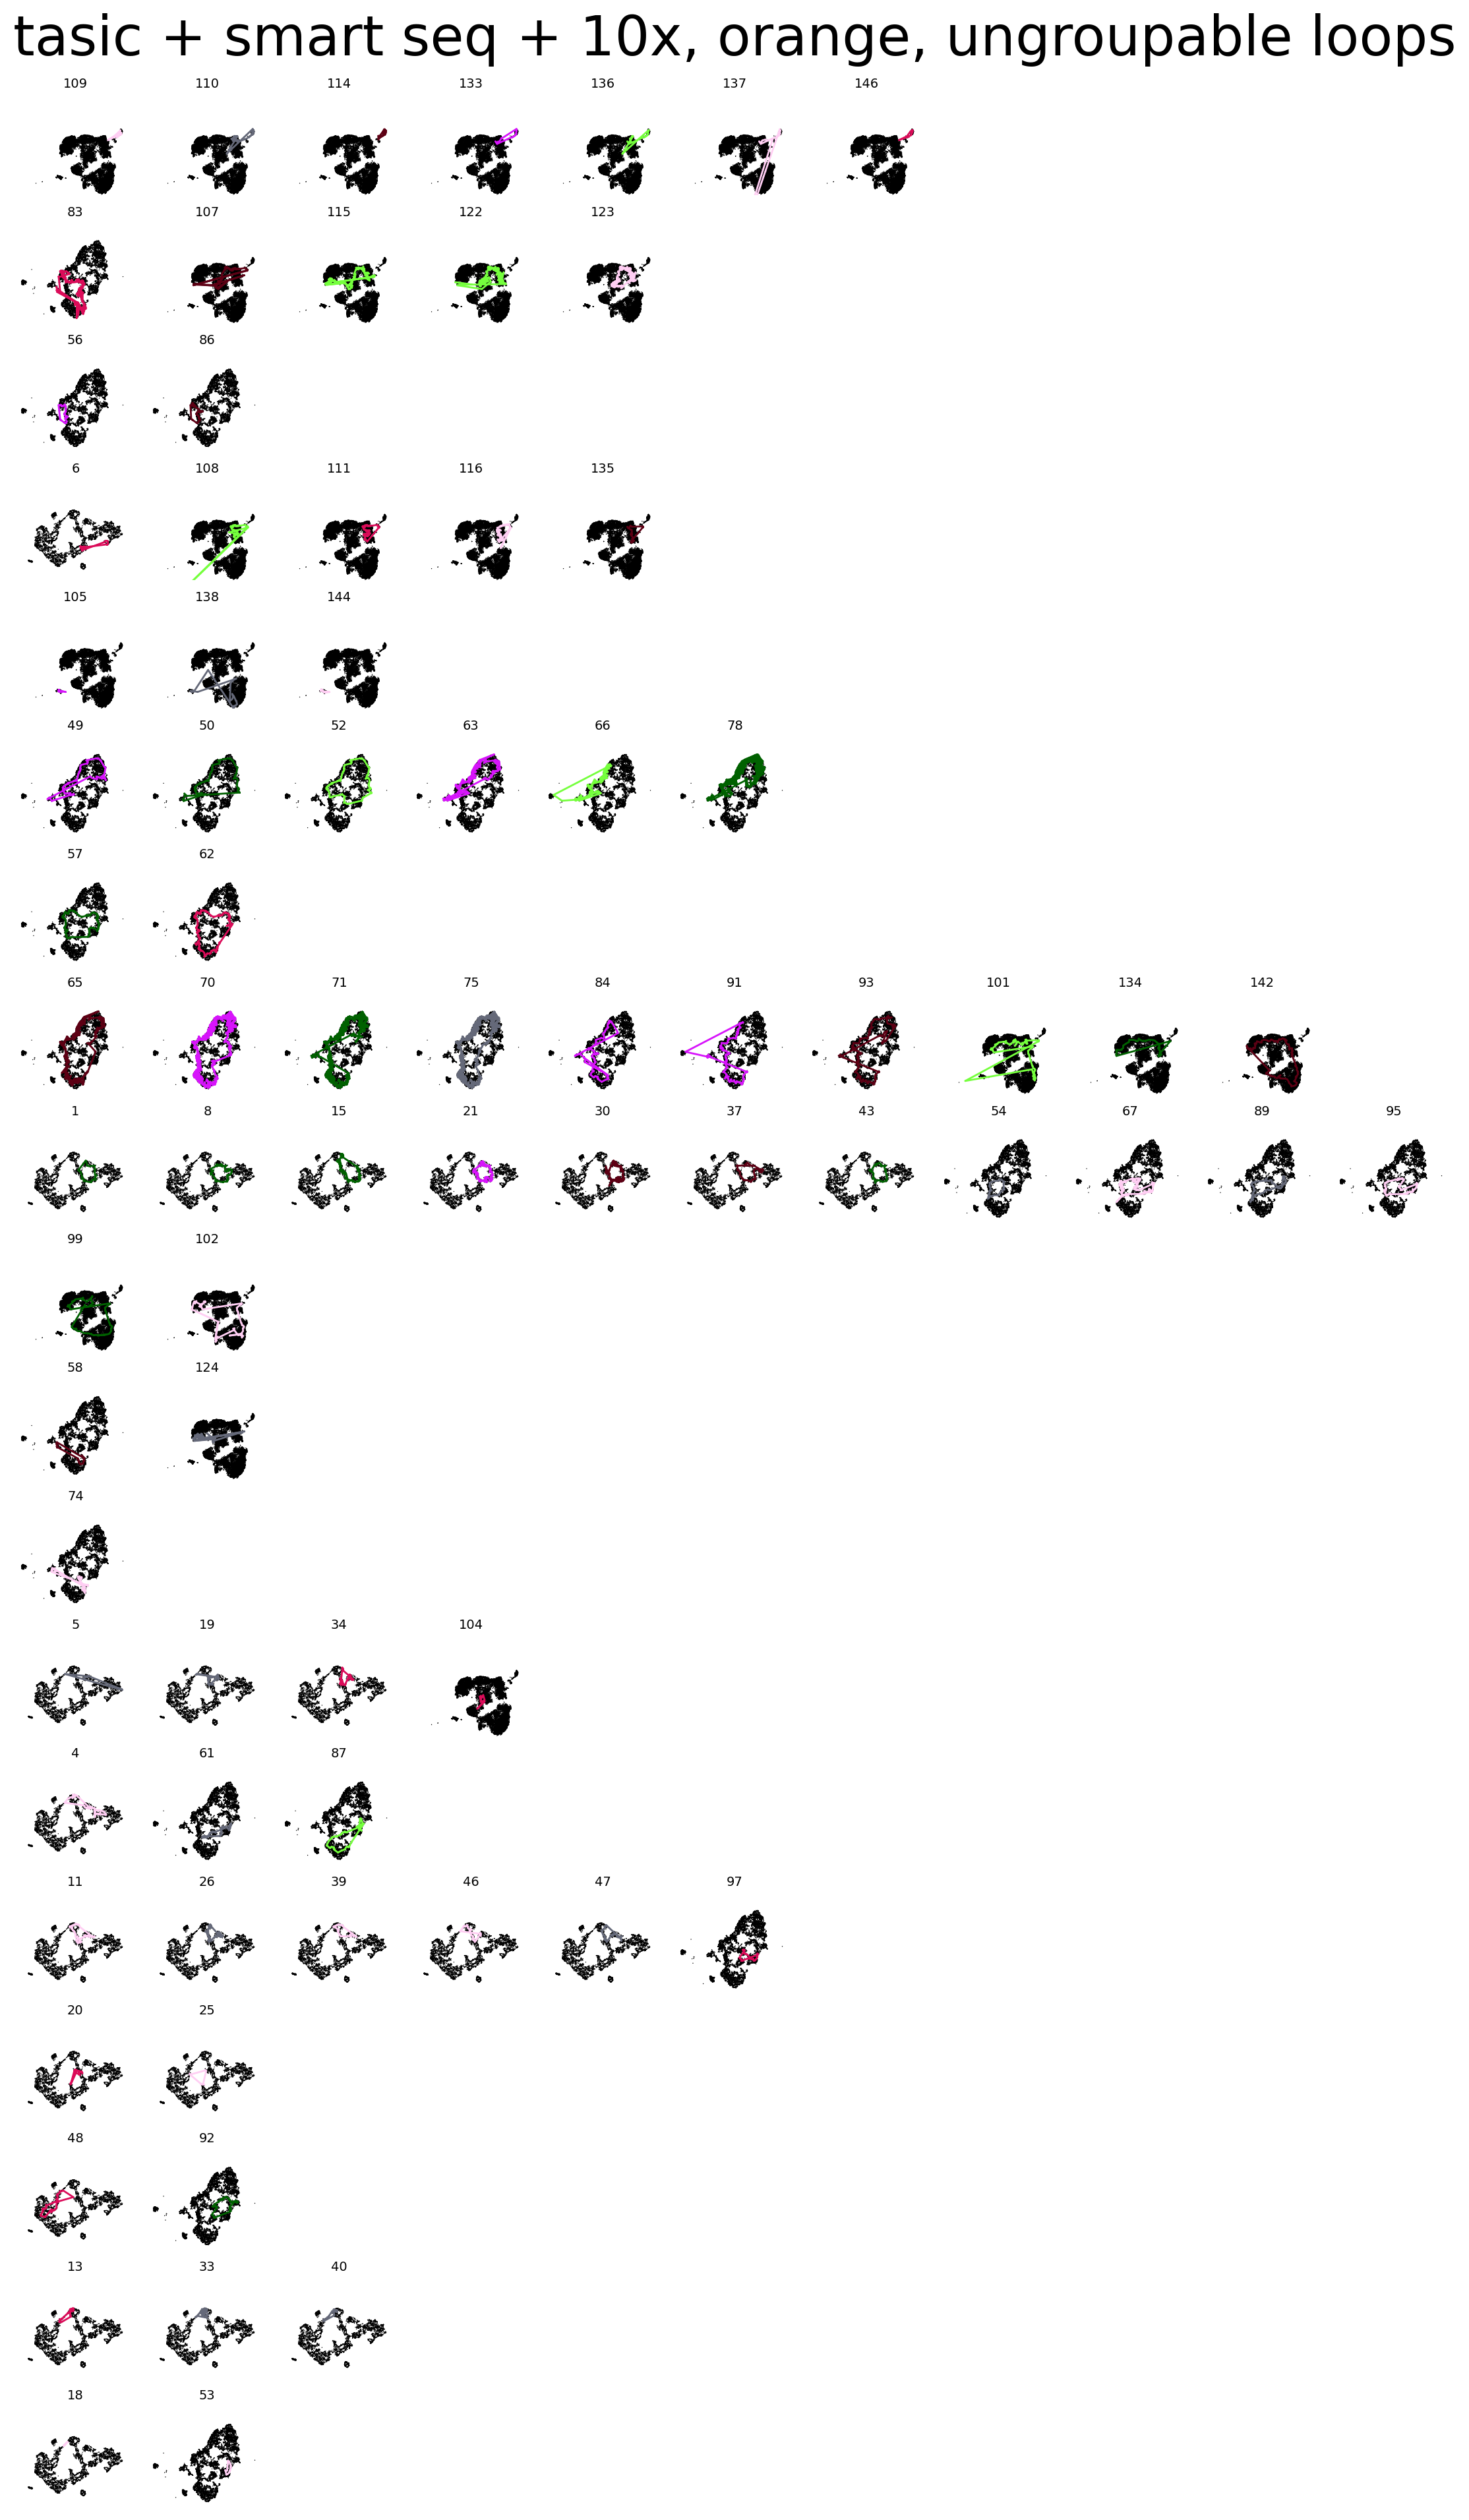

In [393]:
pic_tri_unpigeonhole_loops(partition, trim_list_of_communities,ticks,  "tasic_orange", "yao_smart_orange", "yao_10x_male_orange_20k", "orange", saveas = None) #, saveas = "orange_fig_tri_ungro.png"

Done with tasic_orange None euclidean n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None euclidean n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_8_kernel_

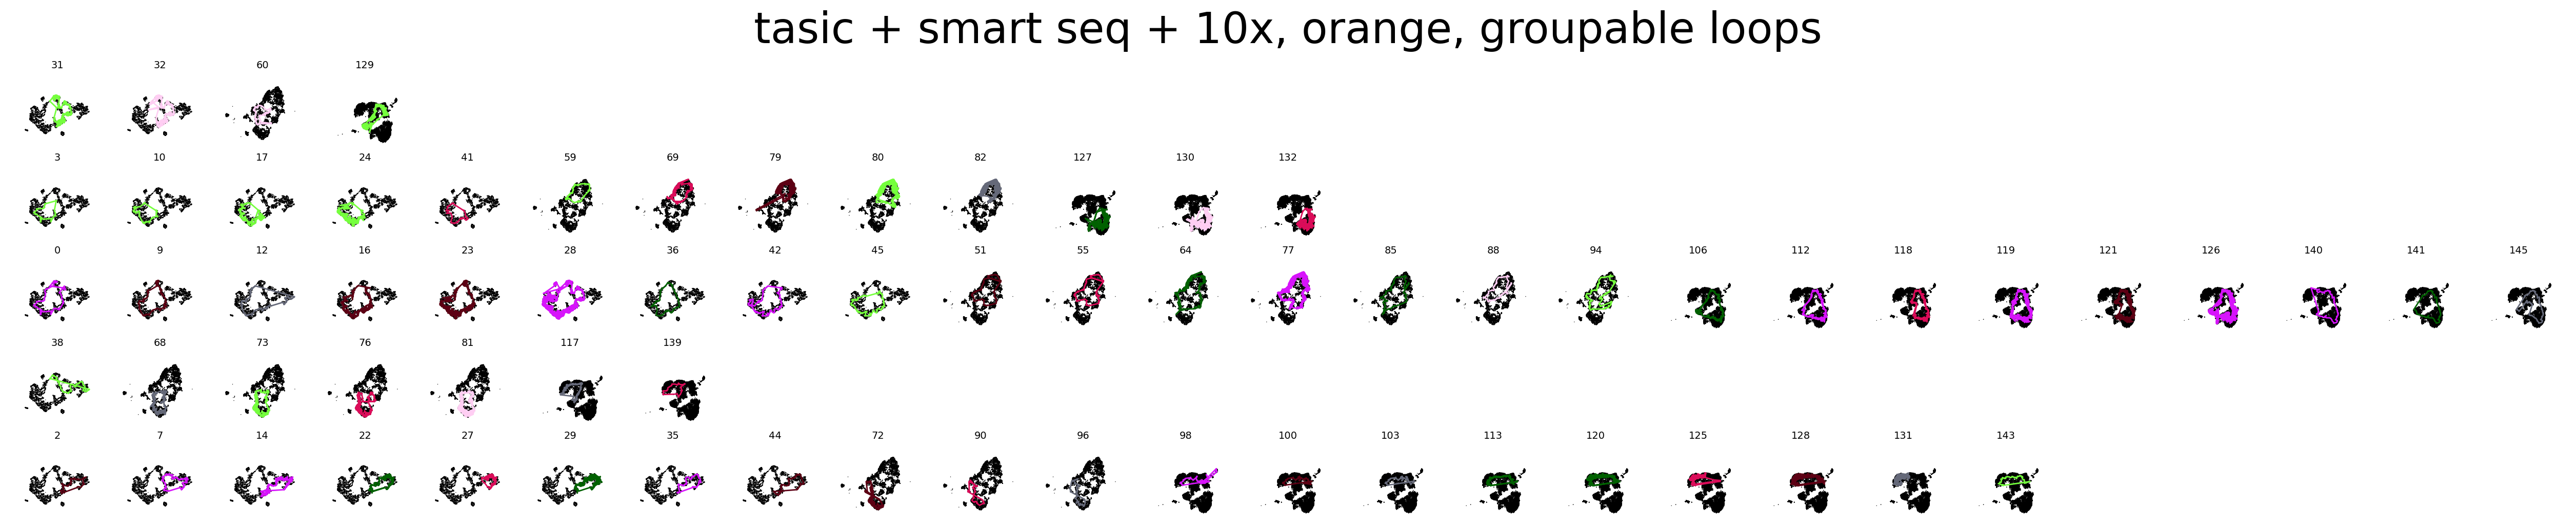

In [392]:
pic_tri_pigeonhole_loops(partition, trim_list_of_communities, ticks,  "tasic_orange", "yao_smart_orange", "yao_10x_male_orange_20k", "orange") #, saveas = "orange_fig_tri.png"

# histogram

In [ ]:
def weighted_top_percentage(l, percetage):
    list_loops= list(chain(*l))
    counter = Counter(list_loops)
    
    all_keys = [key for key, count in counter.most_common()]
    all_counts = [count for key, count in counter.most_common()]
    
    total_count_perc = sum(counts)*percetage
    cumulative_count = 0

    for i, count in enumerate(counts):
        cumulative_count += count
        if cumulative_count >= total_count_perc:
            break
    perc_keys = all_keys[:i+1]
    perc_freq = [a/total_count_perc for a in all_counts[:i+1]]
    
    return all_keys, all_counts, perc_keys, perc_freq

In [ ]:
def unweighted_top_percentage(l, percetage, clusters):
    freqs = []
    for loop in l:
        counts = [list(loop).count(cluster) for cluster in clusters]
        sum = len(loop)
        freq = [a/sum for a in counts]
        
        freqs.append(freq)    

    average_freq = np.mean(np.array(freqs), axis = 0)
    
    
    ordered_idx_freq = sorted(enumerate(average_freq), key=lambda x: x[1], reverse=True)

    ordered_freq = [value for index, value in ordered_idx_freq]
    ordered_idx = [index for index, value in ordered_idx_freq]
    ordered_clusters = [clusters[index] for index in ordered_idx]
    cumu_freq = np.cumsum(ordered_freq)
    
    num_perc = len(cumu_freq[cumu_freq<0.9])
    
    perc_sum = np.sum(ordered_freq[:num_perc+1])
    perc_freq = [freq/perc_sum for freq in ordered_freq[:num_perc+1]]
    perc_clusters = ordered_clusters[:num_perc+1]
    return perc_freq, perc_clusters

In [ ]:
#balanced version.......working on this.....didnt finish bc dont think its too promissing......
def hist_tri_pigeonhole_loops_balance(partition, trim_list_of_communities, ticks, dataset_tasic, dataset_yao, dataset_10x, cell_group, saveas = None):
    rows = len(trim_list_of_communities)-1
    columns = 1
    tasic_to_yao = load_dict(os.path.join(get_path("data") ,"yao", "tasic_to_yao.pkl"))
    fig, ax = plt.subplots(columns, rows, figsize=(rows*3,columns*5), constrained_layout=True)
    
    distances = {
        "euclidean": [{}],
            "diffusion": [
            {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
        ],
        "eff_res": [
            {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
            {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        ],
    }
    root_path = get_path("data")
    all_res_tasic = load_multiple_res(datasets=dataset_tasic, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_tasic = {key: value for distance in all_res_tasic.values() for key, value in distance.items()}
    all_res_yao = load_multiple_res(datasets=dataset_yao, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_yao = {key: value for distance in all_res_yao.values() for key, value in distance.items()}
    all_res_10x = load_multiple_res(datasets=dataset_10x, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_10x = {key: value for distance in all_res_10x.values() for key, value in distance.items()}
    
    # colors = ['#d714fb', '#006100', '#5d0014', '#75ff3d', '#ffcef3', '#656979', '#db0c59']
    # idxs = [i for l in trim_list_of_communities[:-1] for i in l]
    
    _, _, _, _, d_tasic = load_dataset(root_path, "tasic", k=15)    
    _, _, _, _, d_smart = load_dataset(root_path, "yao_smart", k=15)
    _, _, _, _, d_10x_male = load_dataset(root_path, "yao_10x_male", k=15)
    if cell_group == "orange":
        #clusters
        clusters = [cluster for i, cluster in enumerate(d_10x_male["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]
        #tasic
        mask_Pvalb = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Pvalb")
        mask_Sst = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Sst")
        mask_tasic = np.maximum(mask_Pvalb, mask_Sst)
        
        
        idx_orange_tasic = [i for i, cluster in enumerate(d_tasic["clusterNames"]) 
              if "Sst" in cluster or "Pvalb" in cluster]
        counter_all = Counter(d_tasic["clusters"])
        clusters_idx = [list(counter_all.keys()).index(idx) for idx in idx_orange_tasic]
        counter_cellgroups_tasic = np.array([i for i in counter_all.values()])[clusters_idx]
        to_yao_clusters = np.array([tasic_to_yao[i] for i in d_tasic["clusterNames"][idx_orange_tasic]])
        counts_tasic = np.zeros(len(clusters))
        for i, cluster in enumerate(clusters):
            idx = np.where(to_yao_clusters == cluster)[0]
            if len(idx)!=0 :
                counts_tasic[i] = sum(counter_cellgroups_tasic[idx])
        counter_cellgroups_tasic = counts_tasic.astype(int)
        
        
        #yao smart seq
        idx_orange_smart = [i for i, cluster in enumerate(d_smart["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
        mask_smart = [idx in idx_orange_smart for idx in d_smart['clusters']]
        
        counter_all = Counter(d_smart["clusters"])
        clusters_idx = [list(counter_all.keys()).index(idx) for idx in idx_orange_smart]
        counter_cellgroups_smart = np.array([i for i in counter_all.values()])[clusters_idx]
        
        #yao 10x
        idx_orange_10x_male = [i for i, cluster in enumerate(d_10x_male["clusterNames"]) 
                if "_Sst" in cluster or "_Pvalb" in cluster]
        mask_10x_male = [idx in idx_orange_10x_male for idx in d_10x_male['clusters']]
        total_size = len(d_10x_male["clusters"][mask_10x_male])
        np.random.seed(0)
        mask = np.random.choice(total_size, 20000, replace=False)

        counter_all = Counter(d_10x_male["clusters"][mask_10x_male][mask])
        clusters_idx = [list(counter_all.keys()).index(idx) for idx in idx_orange_10x_male]
        counter_cellgroups_10x_male = np.array([i for i in counter_all.values()])[clusters_idx]
        
    # elif cell_group == "purple":   #didnt finish    
    #     #clusters
    #     clusters = [cluster for i, cluster in enumerate(d_10x_male["clusterNames"]) 
    #               if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
    #     #tasic
    #     mask_Vip = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Vip")
    #     mask_Sncg = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Sncg")
    #     mask_Serpinf1 = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Serpinf1")
    #     mask_Lamp5 = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Lamp5")
    #     mask_Lamp5_Lhx6 = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Lamp5 Lhx6")  
    #     mask_lamp5_wo_Lhx6 = [a and not b for a, b in zip(mask_Lamp5, mask_Lamp5_Lhx6)]
    #     mask_tasic = mask_Vip | mask_Sncg | mask_Serpinf1 | mask_lamp5_wo_Lhx6
    #     #yao smart seq
    #     idx_purple_smart = [i for i, cluster in enumerate(d_smart["clusterNames"]) 
    #           if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
    #     mask_smart = [idx in idx_purple_smart for idx in d_smart['clusters']]
    #     #yao 10x
    #     idx_purple_10x_male = [i for i, cluster in enumerate(d_smart["clusterNames"]) 
    #           if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
    #     mask_10x_male = [idx in idx_purple_10x_male for idx in d_smart['clusters']]
    
    
    total_counts = counter_cellgroups_tasic + counter_cellgroups_smart + counter_cellgroups_10x_male
    
    idxs_communities= []
    for l in trim_list_of_communities[:-1]:
        idxs_a_community = []
        for idx in l:
            if idx <49 :
                res = new_all_res_tasic[list(new_all_res_tasic.keys())[int(np.floor(idx/7))]]
                life_times_loops = get_life_times(res, dim=1)
                loop_idx_sorted = np.argsort(life_times_loops)[::-1][idx%7]
                edge = res["cycles"][1][loop_idx_sorted]
                cell_type_idx = list(set(edge.flatten()))
                
                masked_type = d_tasic['clusters'][mask_tasic]
                loop_type_idx = masked_type[cell_type_idx]
                loop_type_idx = sorted(loop_type_idx)
                cell_type =  d_tasic['clusterNames'][loop_type_idx]
                cell_type = [tasic_to_yao[tasic_type] for tasic_type in cell_type]
            elif idx >= 40 and idx < 98:
                res = new_all_res_yao[list(new_all_res_tasic.keys())[int(np.floor(idx/7))-7]]
                life_times_loops = get_life_times(res, dim=1)
                loop_idx_sorted = np.argsort(life_times_loops)[::-1][idx%7]
                edge = res["cycles"][1][loop_idx_sorted]
                cell_type_idx = list(set(edge.flatten()))
                
                masked_type = d_smart['clusters'][mask_smart]
                loop_type_idx = masked_type[cell_type_idx]
                loop_type_idx = sorted(loop_type_idx)
                cell_type =  d_smart['clusterNames'][loop_type_idx]
            elif idx >= 98 :
                res = new_all_res_10x[list(new_all_res_tasic.keys())[int(np.floor(idx/7))-14]]
                life_times_loops = get_life_times(res, dim=1)
                loop_idx_sorted = np.argsort(life_times_loops)[::-1][idx%7]
                edge = res["cycles"][1][loop_idx_sorted]
                cell_type_idx = list(set(edge.flatten()))
                
                masked_type = d_10x_male['clusters'][mask_10x_male]
                loop_type_idx = masked_type[cell_type_idx]
                loop_type_idx = sorted(loop_type_idx)
                cell_type =  d_10x_male['clusterNames'][loop_type_idx]
            idxs_a_community.append(cell_type) 
        idxs_communities.append(idxs_a_community)
    
    for i, l in enumerate(idxs_communities):
        _,_, perc_keys, perc_freq = weighted_top_percentage(l, percetage = 1.0)
        for j, freq in enumerate(perc_freq):
            perc_freq[j] = freq/total_counts[np.where(np.array(clusters) == perc_keys[j])[0][0]]
        perc_freq = [a/sum(perc_freq) for a in perc_freq]
        ax[i].barh(perc_keys, perc_freq)
        
        # perc_freq, perc_keys = unweighted_top_percentage(l, percetage=0.9, clusters = clusters)
        # ax[1][i].barh(perc_keys, perc_freq)
        
        
    # return idxs_communities
    # for axx in ax.flat:
    #     axx.axis('off')
    # ax[0][0].set_title("                                    ungroupable loops", fontsize=30)
    fig.suptitle(f"hist, tasic + smart seq + 10x, {cell_group}, groupable loops", fontsize = 30)       
    plt.show()
    if saveas is not None:
        fig.savefig(os.path.join(get_path("figures"), saveas), dpi=300)


Done with tasic_orange None euclidean n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None euclidean n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_8_kernel_

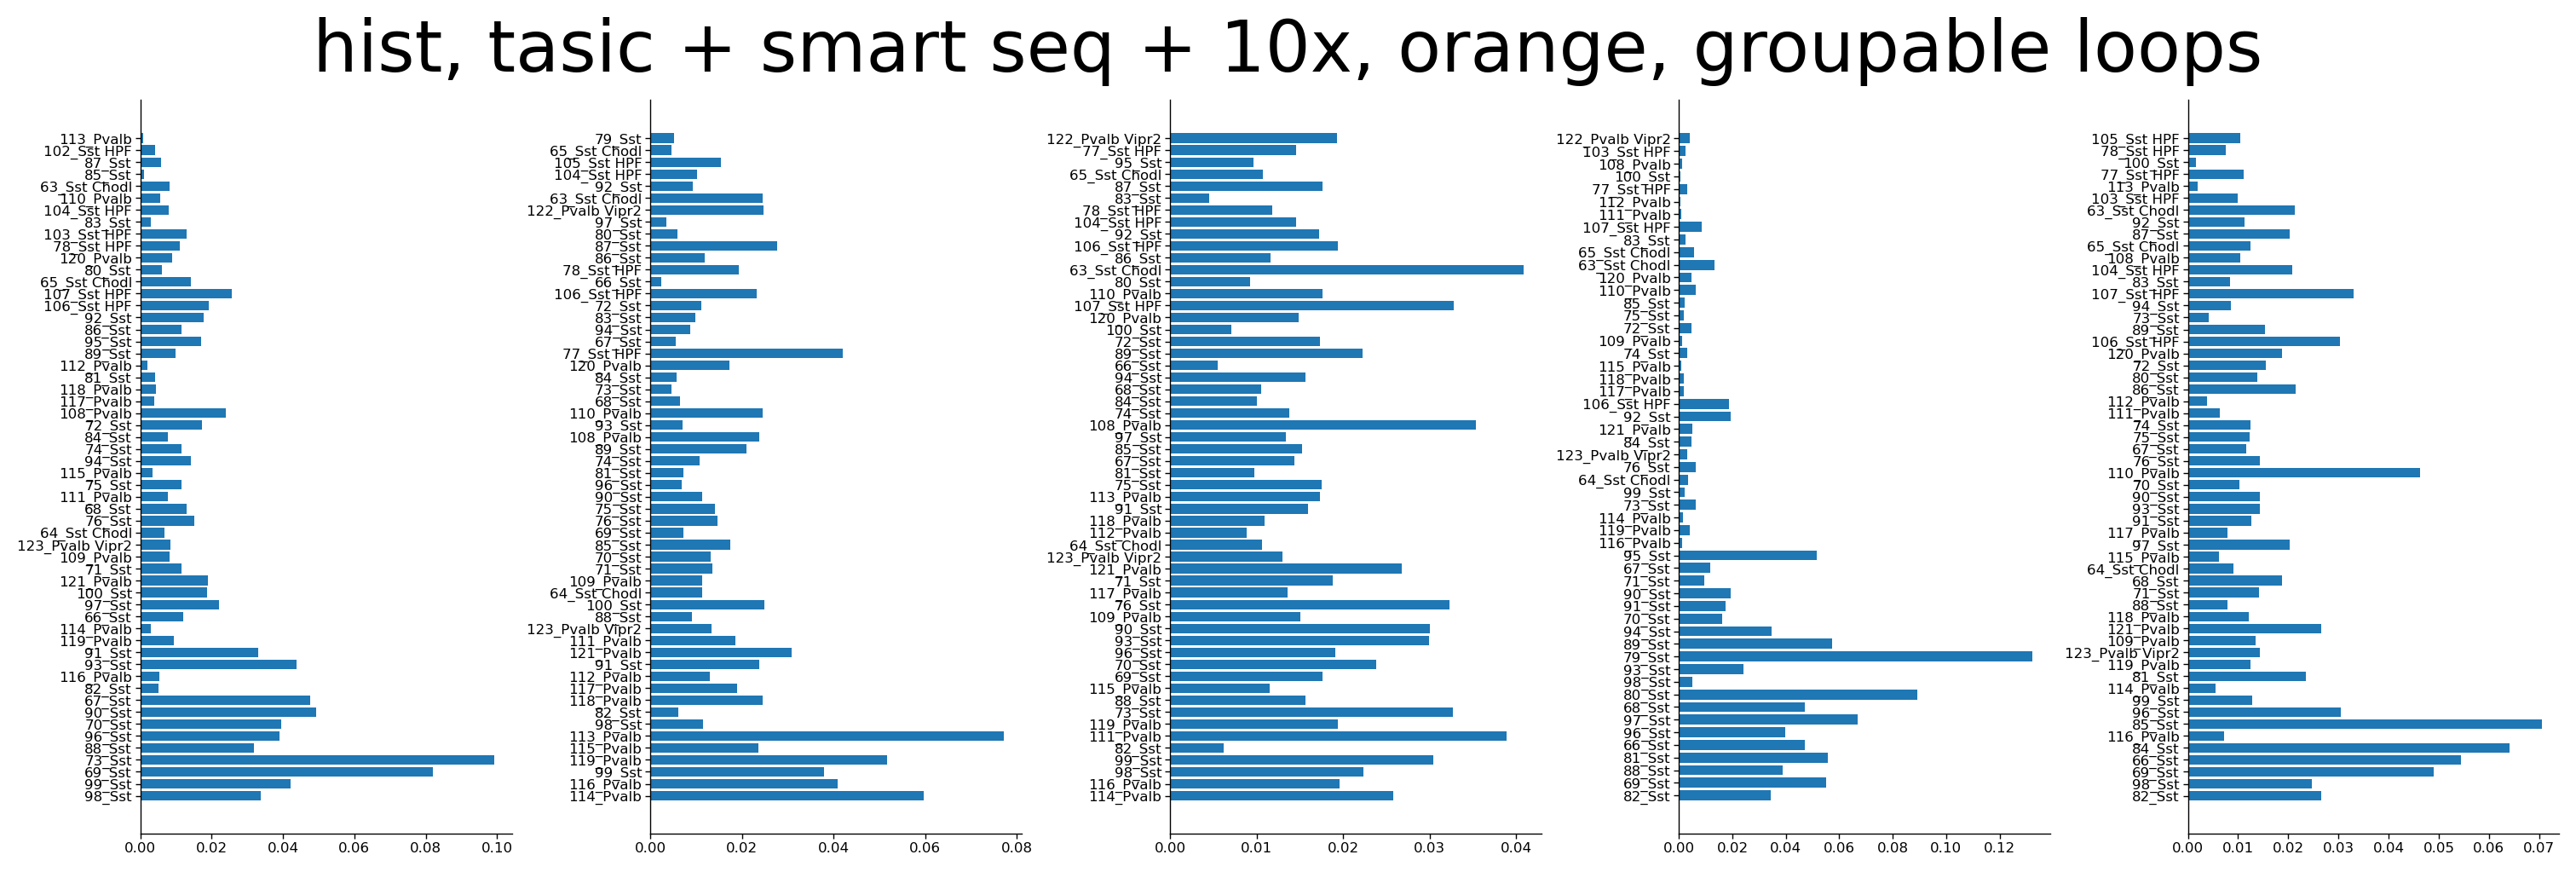

In [ ]:
hist_tri_pigeonhole_loops_balance(partition, trim_list_of_communities, ticks,  "tasic_orange", "yao_smart_orange", "yao_10x_male_orange_20k", "orange") #, saveas = "orange_fig_tri.png"

In [ ]:
#unbalanced version.......
def hist_tri_pigeonhole_loops_unbalanced(partition, trim_list_of_communities, ticks, dataset_tasic, dataset_yao, dataset_10x, cell_group, saveas = None):
    rows = len(trim_list_of_communities)-1
    columns = 2
    tasic_to_yao = load_dict(os.path.join(get_path("data") ,"yao", "tasic_to_yao.pkl"))
    fig, ax = plt.subplots(columns, rows, figsize=(rows*3,columns*3), constrained_layout=True)
    
    distances = {
        "euclidean": [{}],
            "diffusion": [
            {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
        ],
        "eff_res": [
            {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
            {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        ],
    }
    root_path = get_path("data")
    all_res_tasic = load_multiple_res(datasets=dataset_tasic, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_tasic = {key: value for distance in all_res_tasic.values() for key, value in distance.items()}
    all_res_yao = load_multiple_res(datasets=dataset_yao, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_yao = {key: value for distance in all_res_yao.values() for key, value in distance.items()}
    all_res_10x = load_multiple_res(datasets=dataset_10x, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_10x = {key: value for distance in all_res_10x.values() for key, value in distance.items()}
    
    # colors = ['#d714fb', '#006100', '#5d0014', '#75ff3d', '#ffcef3', '#656979', '#db0c59']
    # idxs = [i for l in trim_list_of_communities[:-1] for i in l]
    
    _, _, _, _, d_tasic = load_dataset(root_path, "tasic", k=15)    
    _, _, _, _, d_smart = load_dataset(root_path, "yao_smart", k=15)
    _, _, _, _, d_10x_male = load_dataset(root_path, "yao_10x_male", k=15)
    if cell_group == "orange":
        #clusters
        clusters = [cluster for i, cluster in enumerate(d_10x_male["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]
        #tasic
        mask_Pvalb = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Pvalb")
        mask_Sst = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Sst")
        mask_tasic = np.maximum(mask_Pvalb, mask_Sst)
        #yao smart seq
        idx_orange_smart = [i for i, cluster in enumerate(d_smart["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
        mask_smart = [idx in idx_orange_smart for idx in d_smart['clusters']]
        #yao 10x
        idx_orange_10x_male = [i for i, cluster in enumerate(d_10x_male["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
        mask_10x_male = [idx in idx_orange_10x_male for idx in d_10x_male['clusters']]
    elif cell_group == "purple":       
        #clusters
        clusters = [cluster for i, cluster in enumerate(d_10x_male["clusterNames"]) 
                  if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
        #tasic
        mask_Vip = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Vip")
        mask_Sncg = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Sncg")
        mask_Serpinf1 = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Serpinf1")
        mask_Lamp5 = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Lamp5")
        mask_Lamp5_Lhx6 = np.char.startswith(d_tasic["clusterNames"][d_tasic['clusters']], "Lamp5 Lhx6")  
        mask_lamp5_wo_Lhx6 = [a and not b for a, b in zip(mask_Lamp5, mask_Lamp5_Lhx6)]
        mask_tasic = mask_Vip | mask_Sncg | mask_Serpinf1 | mask_lamp5_wo_Lhx6
        #yao smart seq
        idx_purple_smart = [i for i, cluster in enumerate(d_smart["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
        mask_smart = [idx in idx_purple_smart for idx in d_smart['clusters']]
        #yao 10x
        idx_purple_10x_male = [i for i, cluster in enumerate(d_smart["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
        mask_10x_male = [idx in idx_purple_10x_male for idx in d_smart['clusters']]
    
    idxs_communities= []
    for l in trim_list_of_communities[:-1]:
        idxs_a_community = []
        for idx in l:
            if idx <49 :
                res = new_all_res_tasic[list(new_all_res_tasic.keys())[int(np.floor(idx/7))]]
                life_times_loops = get_life_times(res, dim=1)
                loop_idx_sorted = np.argsort(life_times_loops)[::-1][idx%7]
                edge = res["cycles"][1][loop_idx_sorted]
                cell_type_idx = list(set(edge.flatten()))
                
                masked_type = d_tasic['clusters'][mask_tasic]
                loop_type_idx = masked_type[cell_type_idx]
                loop_type_idx = sorted(loop_type_idx)
                cell_type =  d_tasic['clusterNames'][loop_type_idx]
                cell_type = [tasic_to_yao[tasic_type] for tasic_type in cell_type]
            elif idx >= 40 and idx < 98:
                res = new_all_res_yao[list(new_all_res_tasic.keys())[int(np.floor(idx/7))-7]]
                life_times_loops = get_life_times(res, dim=1)
                loop_idx_sorted = np.argsort(life_times_loops)[::-1][idx%7]
                edge = res["cycles"][1][loop_idx_sorted]
                cell_type_idx = list(set(edge.flatten()))
                
                masked_type = d_smart['clusters'][mask_smart]
                loop_type_idx = masked_type[cell_type_idx]
                loop_type_idx = sorted(loop_type_idx)
                cell_type =  d_smart['clusterNames'][loop_type_idx]
            elif idx >= 98 :
                res = new_all_res_10x[list(new_all_res_tasic.keys())[int(np.floor(idx/7))-14]]
                life_times_loops = get_life_times(res, dim=1)
                loop_idx_sorted = np.argsort(life_times_loops)[::-1][idx%7]
                edge = res["cycles"][1][loop_idx_sorted]
                cell_type_idx = list(set(edge.flatten()))
                
                masked_type = d_10x_male['clusters'][mask_10x_male]
                loop_type_idx = masked_type[cell_type_idx]
                loop_type_idx = sorted(loop_type_idx)
                cell_type =  d_10x_male['clusterNames'][loop_type_idx]
            idxs_a_community.append(cell_type) 
        idxs_communities.append(idxs_a_community)
    
    for i, l in enumerate(idxs_communities):
        _,_, perc_keys, perc_freq = weighted_top_percentage(l, percetage = 0.9)
        ax[0][i].barh(perc_keys, perc_freq)
        
        perc_freq, perc_keys = unweighted_top_percentage(l, percetage=0.9, clusters = clusters)
        ax[1][i].barh(perc_keys, perc_freq)
        
    fig.suptitle(f"hist, tasic + smart seq + 10x, {cell_group}, groupable loops", fontsize = 30)       
    plt.show()
    if saveas is not None:
        fig.savefig(os.path.join(get_path("figures"), saveas), dpi=300)


Done with tasic_orange None euclidean n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None euclidean n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_8_kernel_

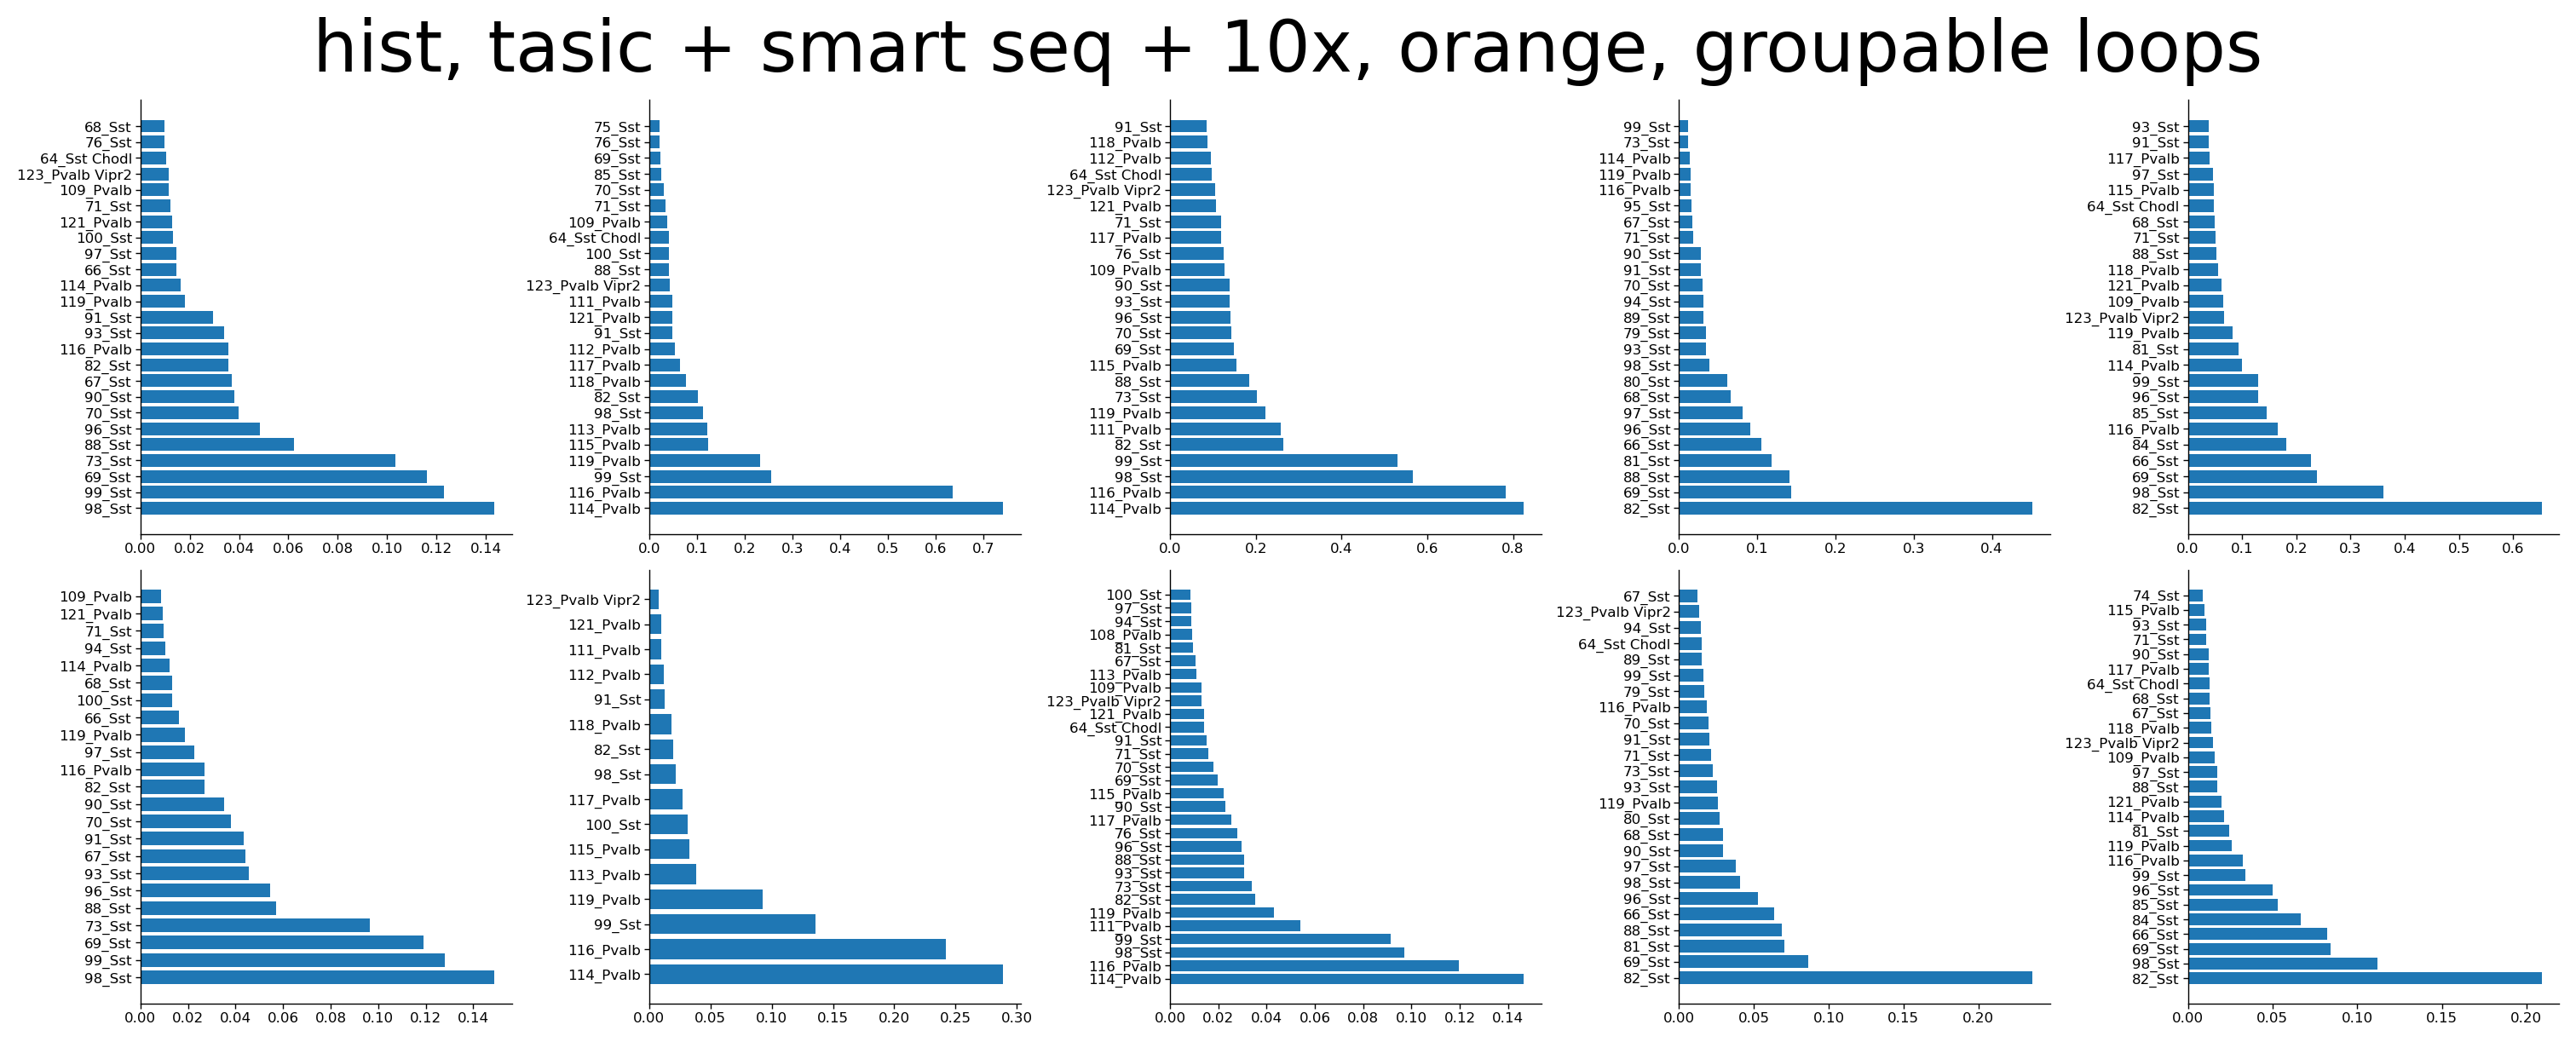

In [ ]:
trylist = hist_tri_pigeonhole_loops_unbalanced(partition, trim_list_of_communities, ticks,  "tasic_orange", "yao_smart_orange", "yao_10x_male_orange_20k", "orange") #, saveas = "orange_fig_tri.png"

# some functions?

In [390]:
def pic_tri_pigeonhole_loops(partition, trim_list_of_communities, ticks, dataset_tasic, dataset_yao, dataset_10x, cell_group, saveas = None):
    
    rows = len(trim_list_of_communities)-1
    columns = np.max([list(partition.values()).count(value) for value in range(rows)])

    fig, ax = plt.subplots(rows, columns, figsize=(columns*1, rows*1), constrained_layout=True)
    
    distances = {
        "euclidean": [{}],
            "diffusion": [
            {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
        ],
        "eff_res": [
            {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
            {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        ],
    }
    root_path = get_path("data")
    all_res_tasic = load_multiple_res(datasets=dataset_tasic, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_tasic = {key: value for distance in all_res_tasic.values() for key, value in distance.items()}
    all_res_yao = load_multiple_res(datasets=dataset_yao, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_yao = {key: value for distance in all_res_yao.values() for key, value in distance.items()}
    all_res_10x = load_multiple_res(datasets=dataset_10x, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_10x = {key: value for distance in all_res_10x.values() for key, value in distance.items()}
    
    
    plot_loops = True
    colors = ['#d714fb', '#006100', '#5d0014', '#75ff3d', '#ffcef3', '#656979', '#db0c59']
    idxs = [i for l in trim_list_of_communities[:-1] for i in l]
    idx = 0
    pos_list = [0]*rows
    while idx <= 3*49:
        if idx not in idxs:
            idx+=1
            pass
        else: 
            if idx<49 and idx in idxs:
                res = new_all_res_tasic[list(new_all_res_tasic.keys())[int(np.floor(idx/7))]]
                if cell_group == "orange":
                    embd_n_mask = embd_tasic_orange
                elif cell_group == "purple":
                    embd_n_mask = embd_tasic_purple
            elif idx >= 40 and idx < 98 and idx in idxs:
                res = new_all_res_yao[list(new_all_res_tasic.keys())[int(np.floor(idx/7))-7]]
                if cell_group == "orange":
                    embd_n_mask =  embd_smart_orange
                elif cell_group == "purple":
                    embd_n_mask =  embd_smart_purple
            elif idx >= 98 and idx in idxs:
                res = new_all_res_10x[list(new_all_res_tasic.keys())[int(np.floor(idx/7))-14]]
                if cell_group == "orange":
                    embd_n_mask = embd_10x_orange
                elif cell_group == "purple":
                    embd_n_mask = embd_10x_purple
            life_times_loops = get_life_times(res, dim=1)
            loop_idx_sorted = np.argsort(life_times_loops)[::-1][:7]
            
            row = [i for i, l in enumerate(trim_list_of_communities[:-1]) if idx in l][0]
            cax = ax[row][pos_list[row]]
            cax.set_title(idx, fontsize=7)
            if cell_group == "orange":
                if idx<49:
                    cax.set_ylim((30,80))
                elif idx >=40 and idx < 98:
                    cax.set_xlim((-85,0))
                    cax.set_ylim((-30,30))
                else:
                    cax.set_ylim((30, 90))
                    
            elif cell_group == "purple":
                if idx<49:
                    cax.set_ylim((-40,40))
                elif idx >=40 and idx < 98:
                    cax.set_ylim((0,80))
                else:
                    cax.set_xlim((-75, -60))
                    cax.set_ylim((-40, 40))
            plot_scatter(cax, embd_n_mask, y="k", s=1, alpha=1, scalebar=False)
            plot_edges_on_scatter(ax=cax,
                                edge_idx=res["cycles"][1][loop_idx_sorted[idx%7]],
                                x=embd_n_mask,
                                color=colors[idx%7],
                                linewidth=1)
            pos_list[row]+=1
            idx+=1
    for axx in ax.flat:
        axx.axis('off')
    # ax[10][0].set_title("                                    ungroupable loops", fontsize=30)
    fig.suptitle(f"tasic + smart seq + 10x, {cell_group}, groupable loops", fontsize = 30)       
    plt.show()
    if saveas is not None:
        fig.savefig(os.path.join(get_path("figures"), saveas), dpi=300)


In [391]:
def pic_tri_unpigeonhole_loops(partition, trim_list_of_communities, ticks, dataset_tasic, dataset_yao, dataset_10x, cell_group, saveas = None):
    rows = len(trim_list_of_communities[-1])
    columns = np.max([len(i) for i in trim_list_of_communities[-1]])

    fig, ax = plt.subplots(rows, columns, figsize=(columns*1, rows*1), constrained_layout=True)
    
    distances = {
        "euclidean": [{}],
            "diffusion": [
            {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
        ],
        "eff_res": [
            {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
            {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        ],
    }
    root_path = get_path("data")
    all_res_tasic = load_multiple_res(datasets=dataset_tasic, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_tasic = {key: value for distance in all_res_tasic.values() for key, value in distance.items()}
    all_res_yao = load_multiple_res(datasets=dataset_yao, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_yao = {key: value for distance in all_res_yao.values() for key, value in distance.items()}
    all_res_10x = load_multiple_res(datasets=dataset_10x, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_10x = {key: value for distance in all_res_10x.values() for key, value in distance.items()}
     
    plot_loops = True
    colors = ['#d714fb', '#006100', '#5d0014', '#75ff3d', '#ffcef3', '#656979', '#db0c59']
    idxs = [i for l in trim_list_of_communities[-1] for i in l]
    idx = 0
    pos_list = [0]*rows
    while idx <= 3*49:
        if idx not in idxs:
            idx+=1
            pass
        else: 
            if idx<49 and idx in idxs:
                res = new_all_res_tasic[list(new_all_res_tasic.keys())[int(np.floor(idx/7))]]
                if cell_group == "orange":
                    embd_n_mask = embd_tasic_orange
                elif cell_group == "purple":
                    embd_n_mask = embd_tasic_purple
            elif idx >= 40 and idx < 98 and idx in idxs:
                res = new_all_res_yao[list(new_all_res_tasic.keys())[int(np.floor(idx/7))-7]]
                if cell_group == "orange":
                    embd_n_mask =  embd_smart_orange
                elif cell_group == "purple":
                    embd_n_mask =  embd_smart_purple
            elif idx >= 98 and idx in idxs:
                res = new_all_res_10x[list(new_all_res_tasic.keys())[int(np.floor(idx/7))-14]]
                if cell_group == "orange":
                    embd_n_mask = embd_10x_orange
                elif cell_group == "purple":
                    embd_n_mask = embd_10x_purple
            life_times_loops = get_life_times(res, dim=1)
            loop_idx_sorted = np.argsort(life_times_loops)[::-1][:7]
            
            row = [i for i, l in enumerate(trim_list_of_communities[-1]) if idx in l][0]
            cax = ax[row][pos_list[row]]
            cax.set_title(idx, fontsize=7)
            if cell_group == "orange":
                if idx<49:
                    cax.set_ylim((30,80))
                elif idx >=40 and idx < 98:
                    cax.set_xlim((-85,0))
                    cax.set_ylim((-30,30))
                else:
                    cax.set_ylim((30, 90))
                    
            elif cell_group == "purple":
                if idx<49:
                    cax.set_ylim((-40,40))
                elif idx >=40 and idx < 98:
                    cax.set_ylim((0,80))
                else:
                    cax.set_xlim((-75, -60))
                    cax.set_ylim((-40, 40))
            plot_scatter(cax, embd_n_mask, y="k", s=1, alpha=1, scalebar=False)
            plot_edges_on_scatter(ax=cax,
                                edge_idx=res["cycles"][1][loop_idx_sorted[idx%7]],
                                x=embd_n_mask,
                                color=colors[idx%7],
                                linewidth=1)
            pos_list[row]+=1
            idx+=1
    for axx in ax.flat:
        axx.axis('off')
    # ax[10][0].set_title("                                    ungroupable loops", fontsize=30)
    fig.suptitle(f"tasic + smart seq + 10x, {cell_group}, ungroupable loops", fontsize = 30)       
    plt.show()
    if saveas is not None:
        fig.savefig(os.path.join(get_path("figures"), saveas), dpi=300)


# special: passing cells of one small loops

In [222]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
seed = 0
k = 15
file_name = os.path.join(root_path,
                         "yao_10x_male",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [224]:
x, y, sknn, pca2, d = load_dataset(root_path, "yao_10x_male_orange", k=15, seed=0)

In [219]:
_, _, _, _, full_d = load_dataset(root_path, "yao_10x_male", k=15)
idx_orange = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
cluster_orange = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange = [idx in idx_orange for idx in full_d['clusters']]
idx_mask_orange = [i for i, idx in enumerate(full_d['clusters']) if idx in idx_orange]
np.random.seed(0)
mm_o = np.random.choice(len(idx_mask_orange), 20000, replace=False)

In [280]:
special_loop = [1, 8, 15, 21, 30, 31, 32, 37, 43, 54, 60, 67, 89, 95]
fre = np.zeros(61)
for i in special_loop:
    if i <49:
        fre+=dist_tasic_orange[list(dist_tasic_orange.keys())[int(np.floor(i/7))+1]][i%7]
    elif i >=49: 
        fre+=dist_yao_orange[list(dist_yao_orange.keys())[int(np.floor((i-49)/7))+1]][i%7]
    
# fre = fre/np.sum(fre)

In [281]:
full_fre = np.zeros(len(d['clusterNames']))
for i, cluster in enumerate(d['clusterNames']):
    if cluster in dist_tasic_orange["cluster_orange"]:
        full_fre[i] = fre[dist_tasic_orange["cluster_orange"].index(cluster)]

In [310]:
cmap = plt.get_cmap('Reds')
colors = np.array([cmap(value+0.1) for value in full_fre])

In [297]:
n_cols = 2
plot_loops = False

width_ratios = [0.75] + [1] * (n_cols - 1)

size = 1

all_res = load_multiple_res(datasets="yao_10x_male_orange_sample", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

res = all_res["euclidean"]["euclidean"]

Done with yao_10x_male_orange_sample None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_orange_sample None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_sample None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_sample None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_sample None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_sample None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_orange_sample None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


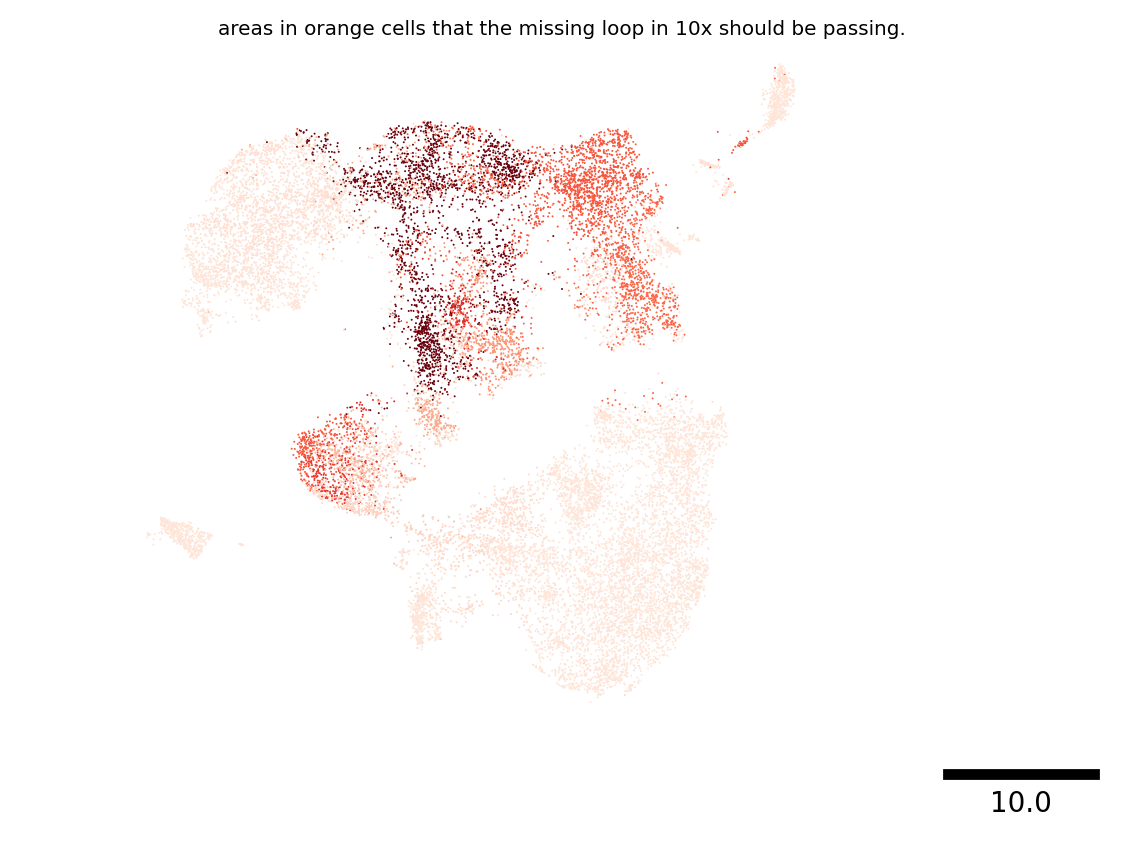

In [312]:
fig, ax = plt.subplots()
plot_scatter(ax, embd[mask_orange][mm_o], y=colors[d['clusters']][mm_o],s=2.0, alpha=1)

fig.suptitle("areas in orange cells that the missing loop in 10x should be passing.")
ax.set_xlim(-65, -10)
ax.set_ylim(20, 70)
fig.savefig(os.path.join(get_path("figures"), f"orange_missing_loops_luminol.png"), dpi=300)